# Explainable AI (SHAP + LIME) Notebook

This notebook contains a ready-to-run Explainable AI pipeline for your `super_ensemble` VotingClassifier. It includes global SHAP, local SHAP, LIME explanations, an aggregation method (Ensemble Explanation Aggregation), and a small real-time simulation example. 

**Assumptions:**
- You already have `super_ensemble` trained in the environment (voting='soft').
- `X_train`, `X_test`, and `y_test` (or `Y_test`) are pandas DataFrames/Series present in the environment.

If you run the full notebook, it will save outputs to `xai_outputs/` and display inline plots where possible.

---

## 1. Install required packages (run once)

If you already installed the packages in your environment, you can skip this cell. Otherwise run the following cell.

 Run this cell if you need to install missing packages
 !pip install shap lime matplotlib scikit-learn pandas numpy

print('If packages were installed, restart the kernel and run the notebook cells again.')

## 2. Imports and helper functions

This cell imports the main libraries and defines helper functions. The functions are adapted from the module provided earlier and save outputs into `xai_outputs/`.

In [2]:
import numpy as np
import pandas as pd
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import json
import os
from IPython.display import Image, display
import joblib
import lightgbm as lgb

In [3]:
# importing super_ensemble 
super_ensemble = joblib.load("../notebooks/final_models/super_ensemble.pkl")

X_train = pd.read_csv("../data/train_test_data/X_train_sm.csv")
X_test = pd.read_csv("../data/train_test_data/X_test.csv")
y_train = pd.read_csv("../data/train_test_data/y_train_sm.csv")
y_test = pd.read_csv("../data/train_test_data/Y_test.csv")

In [10]:
plt.rcParams['figure.figsize'] = (9,6) #setting default size for all plots to get large and clear images

os.makedirs('xai_outputs', exist_ok=True) #folder to save outputa

# Helper: wrapper to get prob for class1 from model
# this function will help get the probability of only the churners class (class 1)
#pred_proba gives probability whether a customer will churn or not (gives both [[0.80,0.20],[0.30, 0.70]..]
#we only need the probability of churners as SHAP, LIME take only single column array
#this helps us always feed correct class probability, no confusion about the labels and consistent output across all XAI methods
def get_pred_proba_class1(model, X):
    probs = model.predict_proba(X)
    return probs[:, 1]

# compute SHAP explanations (global + local object)

def compute_shap_explanations(model, X_train, X_test, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    # model-agnostic explainer using predict_proba for class1
    #function that will return probability of class 1
    def pred_proba_class1(X):
        return model.predict_proba(X)[:,1]
    #Building SHAP explainer
    explainer = shap.Explainer(pred_proba_class1, X_train, feature_names=list(X_train.columns))
    #calculating SHAP values for X_test
    shap_values = explainer(X_test)
    # Global plots
    try:
        shap.summary_plot(shap_values, X_test, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_summary_beeswarm.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap summary plot failed:', e)
    try:
        shap.plots.bar(shap_values, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'shap_feature_importance_bar.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap bar plot failed:', e)
    return explainer, shap_values

# SHAP local for an index
def shap_local_for_index(explainer, shap_values, X_test, i, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    val = shap_values[i]
    try:
        shap.plots.waterfall(val, show=False)
        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, f'shap_waterfall_{i}.png'), dpi=200)
        plt.close()
    except Exception as e:
        print('Warning: shap waterfall failed:', e)
    per_feature_signed = pd.Series(val.values, index=X_test.columns)
    per_feature_abs = per_feature_signed.abs()
    return per_feature_signed, per_feature_abs

# LIME local explanation
def lime_local_for_index(model, X_train, X_test, i, class_names=['No Churn', 'Churn'], save_dir='xai_outputs', num_features=10):
    os.makedirs(save_dir, exist_ok=True)
    lime_explainer = LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=list(X_train.columns),
        class_names=class_names,
        mode='classification',
        discretize_continuous=True,
        random_state=42
    )
    instance = X_test.iloc[i].values
    exp = lime_explainer.explain_instance(instance, model.predict_proba, num_features=num_features)
    lm_list = exp.as_list(label=1)
    lime_weights = pd.Series({feat: weight for feat, weight in lm_list})
    for f in X_train.columns:
        if f not in lime_weights.index:
            lime_weights.loc[f] = 0.0
    lime_weights = lime_weights.loc[X_train.columns]
    with open(os.path.join(save_dir, f'lime_explanation_{i}.txt'), 'w') as fh:
        fh.write('LIME explanation for index {}\n\n'.format(i))
        for feat, weight in lm_list:
            fh.write(f"{feat} : {weight}\n")
    return lime_weights, dict(lm_list)

# Aggregate
def aggregate_explanations(shap_abs_series, lime_series, shap_weight=0.6, lime_weight=0.4):
    df = pd.DataFrame({'shap_raw': shap_abs_series, 'lime_raw': lime_series.abs()}).fillna(0.0)
    scaler = MinMaxScaler()
    df[['shap_norm', 'lime_norm']] = scaler.fit_transform(df[['shap_raw', 'lime_raw']])
    df['final_score'] = shap_weight * df['shap_norm'] + lime_weight * df['lime_norm']
    df = df.sort_values('final_score', ascending=False)
    return df

# end-to-end explain one instance
def explain_instance(model, explainer, shap_values, X_train, X_test, i, shap_weight=0.6, lime_weight=0.4, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    shap_signed, shap_abs = shap_local_for_index(explainer, shap_values, X_test, i, save_dir=save_dir)
    lime_weights, lime_list = lime_local_for_index(model, X_train, X_test, i, save_dir=save_dir)
    agg = aggregate_explanations(shap_abs, lime_weights, shap_weight=shap_weight, lime_weight=lime_weight)
    topk = agg.head(10)
    with open(os.path.join(save_dir, f'aggregated_explanation_{i}.json'), 'w') as fh:
        json.dump(topk['final_score'].to_dict(), fh, indent=2)
    return {'shap_signed': shap_signed, 'shap_abs': shap_abs, 'lime_weights': lime_weights, 'aggregate_df': agg}

# NEW FUNCTION: NATURAL LANGUAGE EXPLANATION
def explain_in_sentence(model, explainer, shap_values, X_train, X_test, index):
    # Predict churn probability
    prob = float(model.predict_proba(X_test.iloc[[index]])[0,1])  
    result = explain_instance(model, explainer, shap_values, X_train, X_test, index)

    # Get top 5 reasons
    top_features = result['aggregate_df'].head(5).index.tolist()

    # Convert feature names into readable form
    clean = [f.replace("_", " ") for f in top_features]

    sentence = (
        f"Customer {index} is predicted to churn with a probability of {prob:.2f}. "
        f"The major reasons contributing to churn are: "
        + ", ".join(clean[:-1])
        + f", and {clean[-1]}."
    )

    return sentence

# real-time stream simulation
def realtime_simulation_stream(model, explainer, shap_values, X_train, X_test, stream_indices, save_dir='xai_outputs'):
    os.makedirs(save_dir, exist_ok=True)
    results = []
    for i in stream_indices:
        x_row = X_test.iloc[[i]]
        pred_proba = model.predict_proba(x_row)[0,1]
        explanation = explain_instance(model, explainer, shap_values, X_train, X_test, i, save_dir=save_dir)
        top_features = explanation['aggregate_df'].head(5).index.tolist()
        results.append({'index': i, 'pred_proba': float(pred_proba), 'top_features': top_features, 'top_scores': explanation['aggregate_df'].head(5)['final_score'].round(4).tolist()})
        print(f"[stream] idx={i} prob={pred_proba:.4f} top_features={top_features}")
    return pd.DataFrame(results)

print('Helpers loaded. Ready for XAI steps.')

Helpers loaded. Ready for XAI steps.


## 3. Quick checks

Run these checks to ensure `super_ensemble` and data variables exist and `predict_proba` works. If any check fails, load or re-fit your model and data before continuing.

In [5]:
# Quick checks - run these cells after loading your model and data

try:
    print('super_ensemble type:', type(super_ensemble))
except Exception as e:
    print('super_ensemble not found in environment. Make sure you have the variable defined. Error:', e)

try:
    print('X_train shape:', X_train.shape)
    print('X_test shape :', X_test.shape)
except Exception as e:
    print('X_train / X_test not found. Error:', e)

# predict_proba test (run only if model exists)
try:
    probs = super_ensemble.predict_proba(X_test[:5])
    print('predict_proba sample shape:', probs.shape)
    print('sample probs:', probs)
except Exception as e:
    print('predict_proba failed. Error:', e)


super_ensemble type: <class 'sklearn.ensemble._voting.VotingClassifier'>
X_train shape: (20108, 350)
X_test shape : (4226, 350)
predict_proba sample shape: (5, 2)
sample probs: [[0.3813644  0.6186356 ]
 [0.42725522 0.57274478]
 [0.77815368 0.22184631]
 [0.66754585 0.33245414]
 [0.60207169 0.39792832]]


## 4. Compute SHAP explainer (global + local object)

This cell computes the SHAP explainer and saves global plots into `xai_outputs/`. This might take a bit of time depending on dataset size.

PermutationExplainer explainer: 4227it [26:36,  2.65it/s]                                                              
C:\Users\KARISHMA\AppData\Local\Temp\ipykernel_19852\1678117053.py:20: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


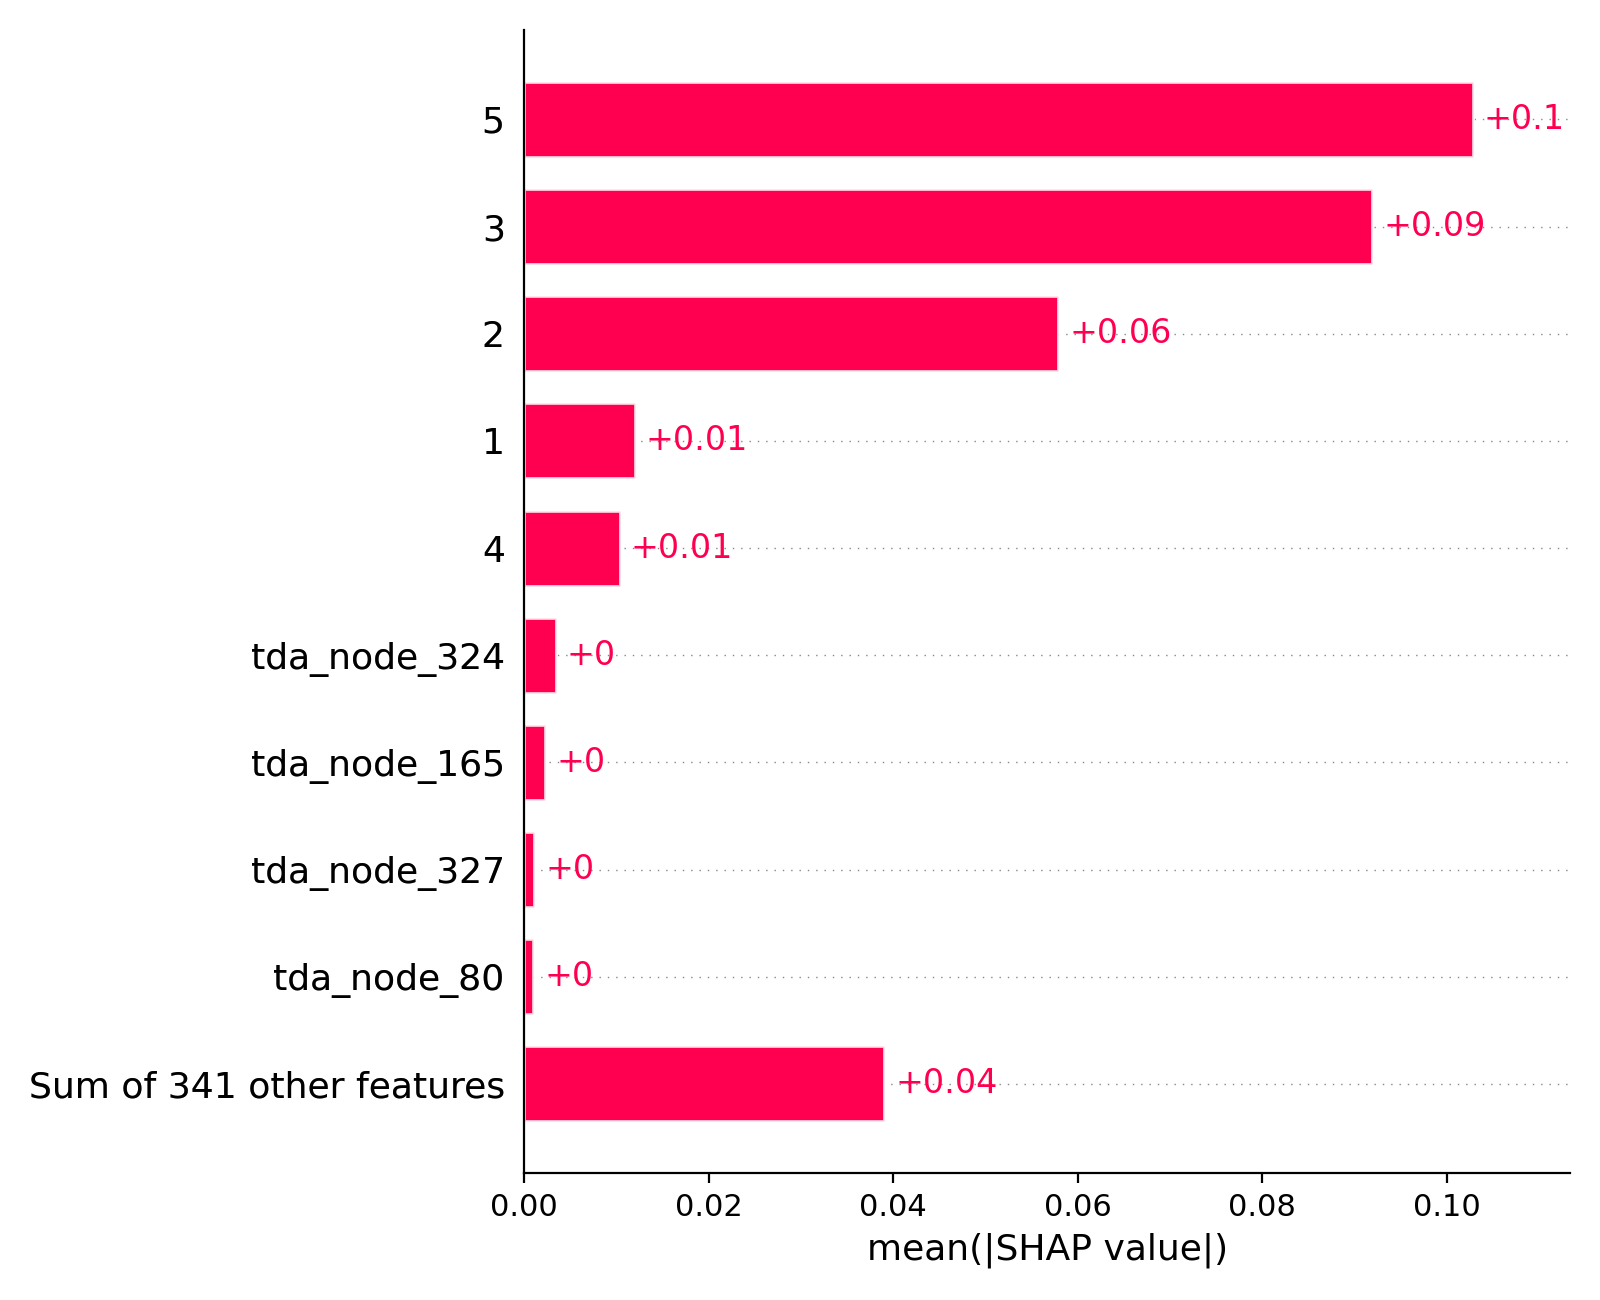

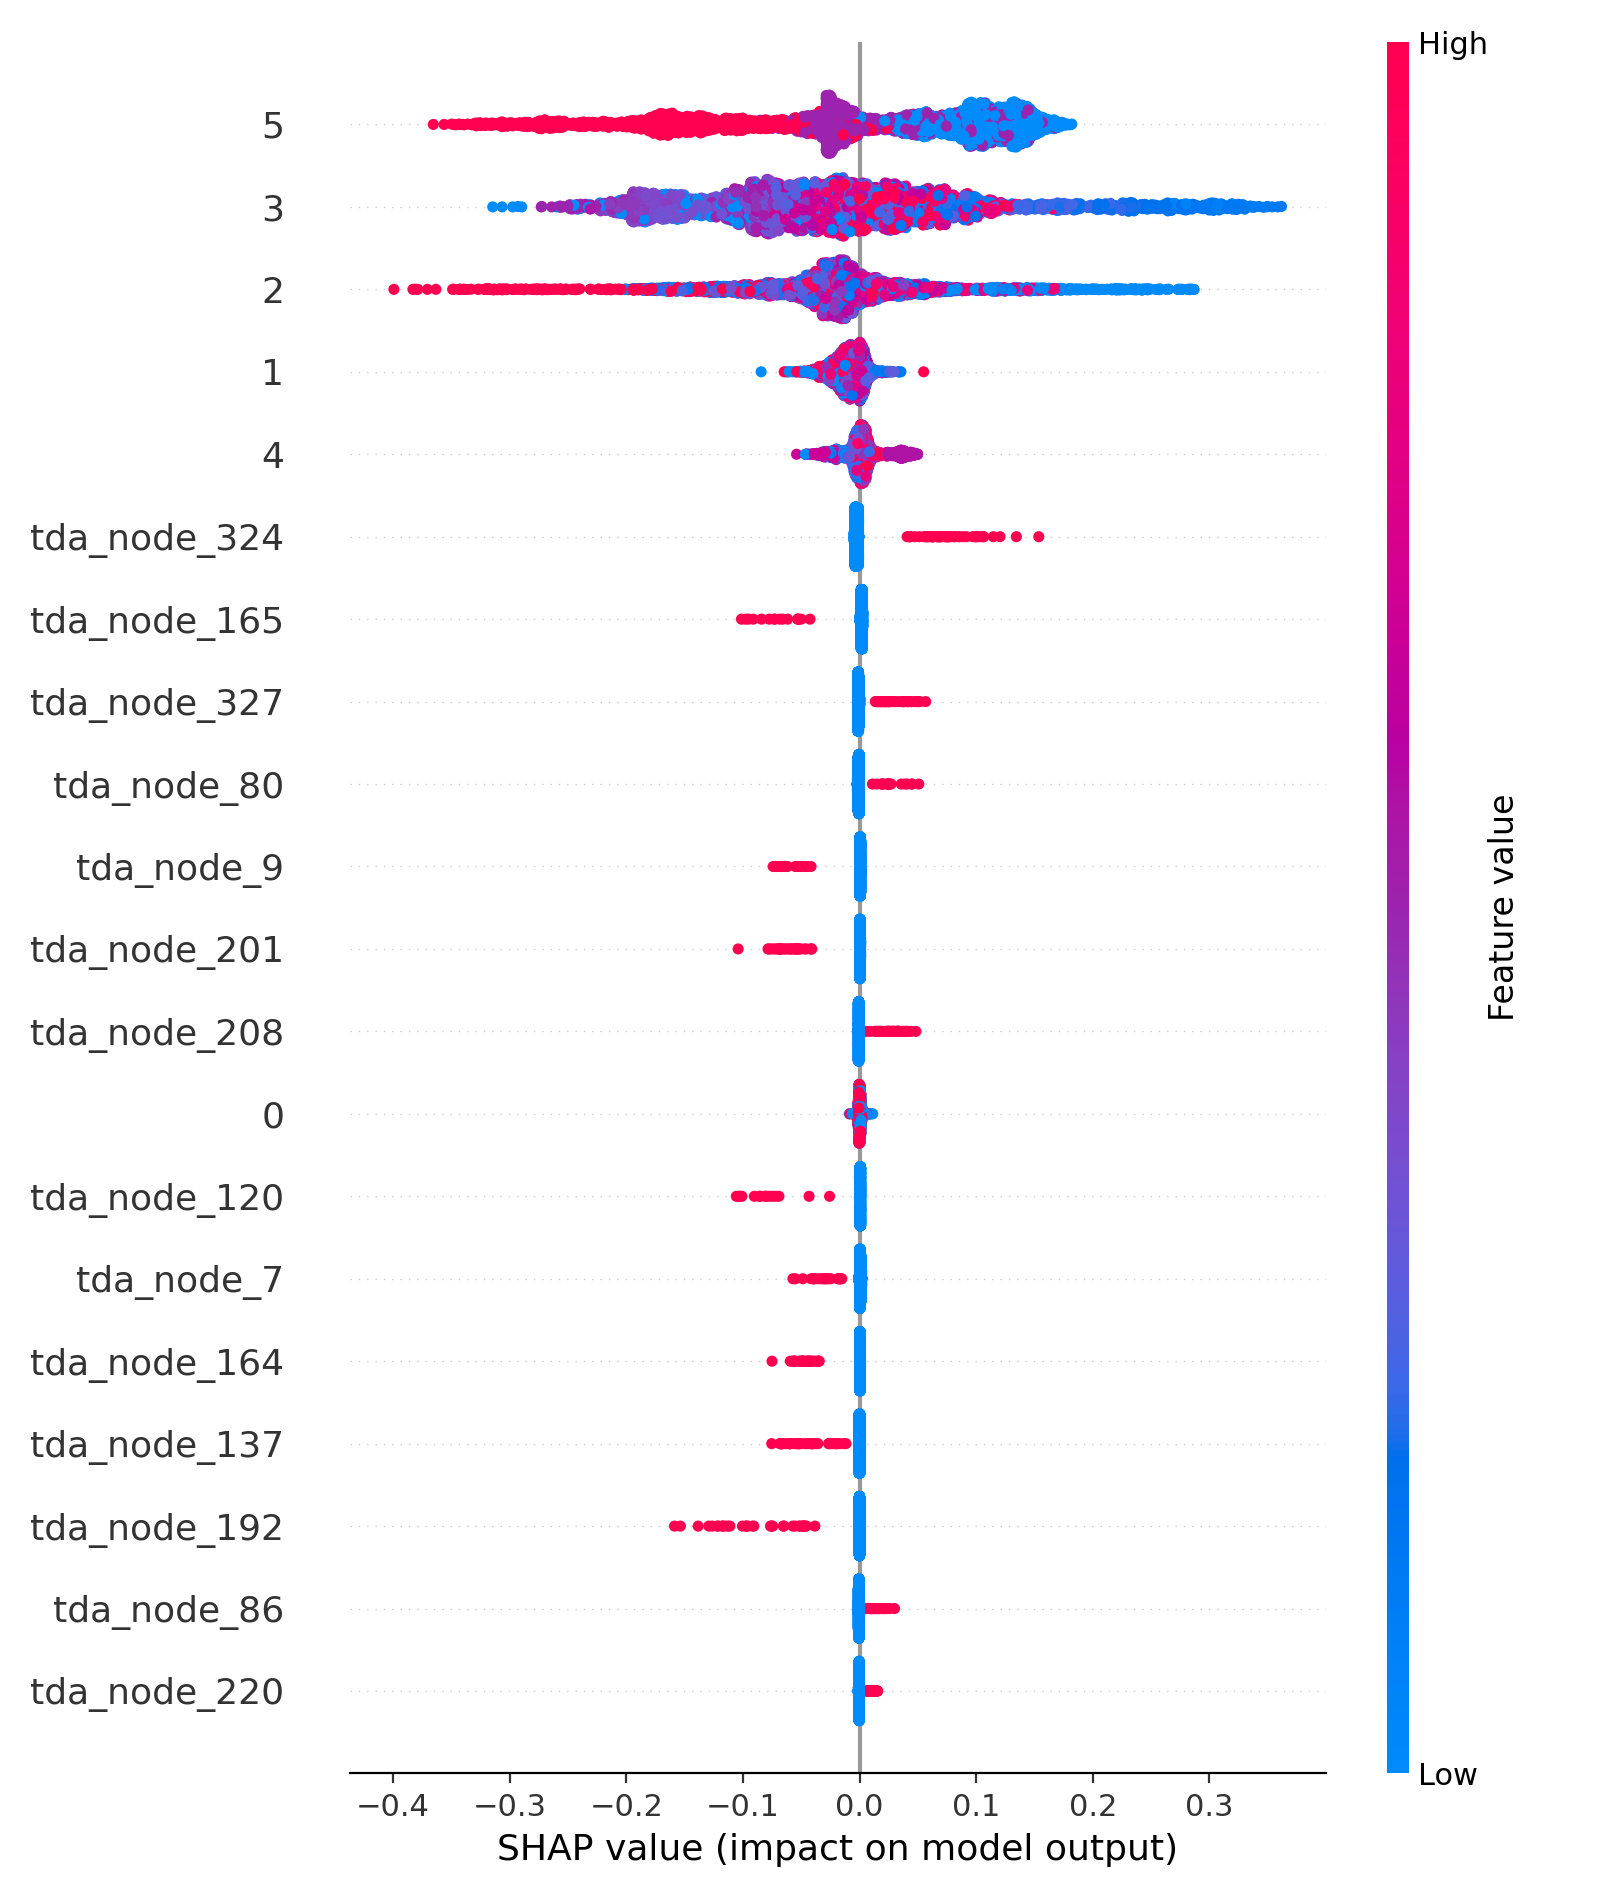

In [6]:
# Compute SHAP explainer
explainer, shap_values = compute_shap_explanations(super_ensemble, X_train, X_test, save_dir='xai_outputs')

# Display saved global plots if available
if os.path.exists('xai_outputs/shap_feature_importance_bar.png'):
    display(Image(filename='xai_outputs/shap_feature_importance_bar.png'))
if os.path.exists('xai_outputs/shap_summary_beeswarm.png'):
    display(Image(filename='xai_outputs/shap_summary_beeswarm.png'))


## 5. Explain a single instance (local SHAP + LIME + Aggregation)

Choose an index `i` from `X_test`. The cell will create SHAP waterfall, LIME text file, and an aggregated JSON with top features.

C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Top aggregated features (final_score):
              shap_raw  lime_raw  shap_norm  lime_norm  final_score
5             0.321809       0.0   1.000000        0.0     0.600000
2             0.061903       0.0   0.192361        0.0     0.115416
3             0.034558       0.0   0.107388        0.0     0.064433
4             0.029709       0.0   0.092319        0.0     0.055391
1             0.025114       0.0   0.078039        0.0     0.046823
tda_node_11   0.010338       0.0   0.032125        0.0     0.019275
tda_node_324  0.001725       0.0   0.005359        0.0     0.003216
tda_node_165  0.001322       0.0   0.004108        0.0     0.002465
tda_node_327  0.000864       0.0   0.002684        0.0     0.001611
tda_node_80   0.000739       0.0   0.002295        0.0     0.001377


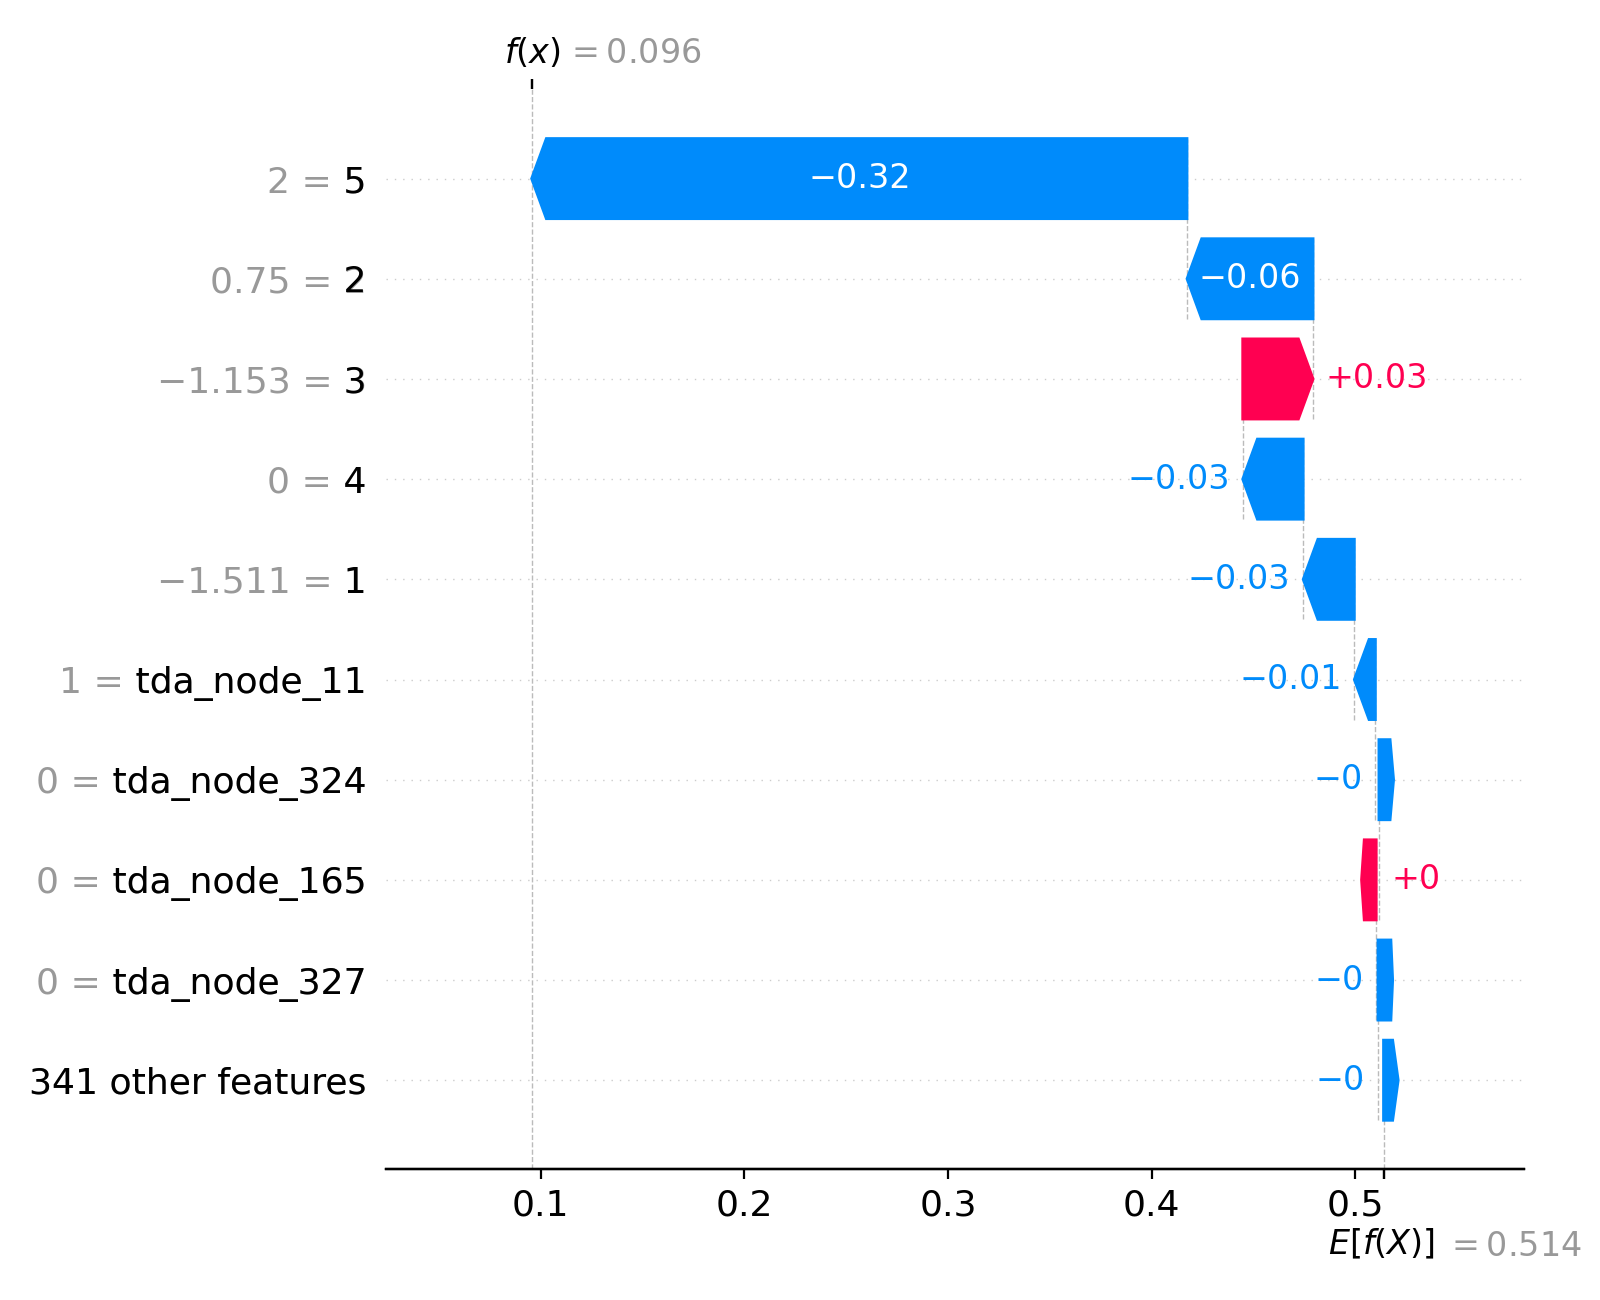


LIME text file (first 20 lines):
LIME explanation for index 10

1.00 < 5 <= 2.00 : -0.25844089781827806
tda_node_16 <= 0.00 : -0.14263042541352963
tda_node_118 <= 0.00 : -0.13508808581928167
tda_node_99 <= 0.00 : -0.11217461222806857
tda_node_324 <= 0.00 : -0.11193199482461204
tda_node_120 <= 0.00 : 0.10023810998114159
tda_node_145 <= 0.00 : -0.08381853973061007
tda_node_94 <= 0.00 : 0.060154689748445116
tda_node_113 <= 0.00 : 0.04274406882471393
tda_node_41 <= 0.00 : -0.0281850461066803

Aggregated JSON top features:
{
  "5": 0.6,
  "2": 0.11541639655285892,
  "3": 0.06443260609073626,
  "4": 0.0553914708055675,
  "1": 0.04682329672118582,
  "tda_node_11": 0.019274840144908573,
  "tda_node_324": 0.0032155878342825296,
  "tda_node_165": 0.002464957016808614,
  "tda_node_327": 0.0016105982129964197,
  "tda_node_80": 0.001377066291296124
}


In [7]:
# Explain instance - change index i as desired
i = 10
res = explain_instance(super_ensemble, explainer, shap_values, X_train, X_test, i=i, shap_weight=0.6, lime_weight=0.4, save_dir='xai_outputs')

print('\nTop aggregated features (final_score):')
print(res['aggregate_df'].head(10))

# show saved images/texts if present
wf = f'xai_outputs/shap_waterfall_{i}.png'
if os.path.exists(wf):
    display(Image(filename=wf))
lt = f'xai_outputs/lime_explanation_{i}.txt'
if os.path.exists(lt):
    print('\nLIME text file (first 20 lines):')
    with open(lt, 'r') as fh:
        for j, line in enumerate(fh):
            if j>=20: break
            print(line.strip())

aggf = f'xai_outputs/aggregated_explanation_{i}.json'
if os.path.exists(aggf):
    print('\nAggregated JSON top features:')
    with open(aggf, 'r') as fh:
        print(fh.read())


## 6. Run a small real-time simulation (streamed rows)

This will simulate streaming a few rows from `X_test` and will print the churn probability and top aggregated features for each streamed customer.

In [8]:
# Simulate streaming - provide indices present in X_test
stream_indices = [10, 20, 30]
stream_df = realtime_simulation_stream(super_ensemble, explainer, shap_values, X_train, X_test, stream_indices, save_dir='xai_outputs')

print('\nStream summary:')
print(stream_df)


C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=10 prob=0.0956 top_features=['5', '2', '3', '4', '1']


C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=20 prob=0.1729 top_features=['5', '2', '3', '4', 'tda_node_25']


C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[stream] idx=30 prob=0.4875 top_features=['5', '2', '3', '1', '4']

Stream summary:
   index  pred_proba               top_features  \
0     10    0.095564            [5, 2, 3, 4, 1]   
1     20    0.172947  [5, 2, 3, 4, tda_node_25]   
2     30    0.487540            [5, 2, 3, 1, 4]   

                              top_scores  
0  [0.6, 0.1154, 0.0644, 0.0554, 0.0468]  
1  [0.6, 0.2447, 0.1512, 0.0634, 0.0617]  
2  [0.6, 0.3012, 0.2605, 0.1257, 0.0284]  


In [12]:

explainer, shap_values = compute_shap_explanations(super_ensemble, X_train, X_test)
sentence = explain_in_sentence(super_ensemble, explainer, shap_values, X_train, X_test, index=25)
print(sentence)


PermutationExplainer explainer: 4227it [25:54,  2.70it/s]                                                              
C:\Users\KARISHMA\AppData\Local\Temp\ipykernel_19852\2609570165.py:28: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)
C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Customer 25 is predicted to churn with a probability of 0.23. The major reasons contributing to churn are: 3, 1, 5, 2, and 4.


In [13]:
sentence = explain_in_sentence(super_ensemble, explainer, shap_values, X_train, X_test, index=20)
print(sentence)

C:\Users\KARISHMA\Desktop\customer-churn-prediction\venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Customer 20 is predicted to churn with a probability of 0.17. The major reasons contributing to churn are: 5, 2, 3, 4, and tda node 25.


## 7. Notes & Next steps

- You can change `shap_weight` and `lime_weight` in the `explain_instance` call to justify your aggregation strategy.
- For more robust LIME results, repeat LIME multiple times and average the weights.
- If your features are scaled and you want human-readable explanations, consider inverse-transforming numeric features before showing them.
- Use `xai_outputs/` images and text files directly in your final report.

---

**End of Explainable AI Notebook**